In [ ]:
# 3.2 线性回归从0开始实现

In [15]:
import torch
import random
import matplotlib.pyplot as plt

In [6]:
def synthetic_data(w,b,num_examples):  #@save
    "生成y=Xw+b+噪声"
    X = torch.normal(0,1,(num_examples,len(w)))
    y = torch.matmul(X,w)+b
    y += torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1))

In [8]:
true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)

In [10]:
features[0],labels[0]

(tensor([0.4249, 0.1933]), tensor([4.4007]))

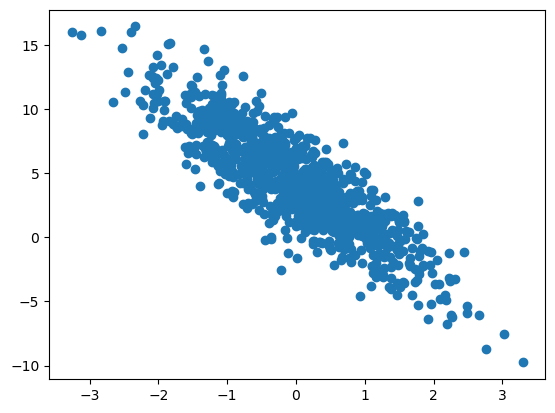

In [16]:
plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy())

In [18]:
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

In [20]:
batch_size = 10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[ 0.1902,  0.7712],
        [ 0.6026,  1.0941],
        [ 0.6188,  0.6638],
        [ 1.6722,  0.2788],
        [-2.7898, -0.3692],
        [ 0.1836, -1.3947],
        [ 0.4650,  0.7022],
        [-0.4264,  0.9608],
        [ 2.0414,  0.1550],
        [-0.8378, -0.5089]]) 
 tensor([[ 1.9681],
        [ 1.6873],
        [ 3.1756],
        [ 6.6001],
        [-0.1324],
        [ 9.3183],
        [ 2.7274],
        [ 0.1097],
        [ 7.7644],
        [ 4.2653]])


In [23]:
batch_size = 10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[ 0.4607, -0.2089],
        [-2.1296,  1.0961],
        [ 0.3607,  0.4933],
        [ 0.1017,  0.9622],
        [ 0.2415, -1.1155],
        [ 0.6331, -0.7177],
        [ 0.1356,  0.5579],
        [-0.5262,  1.3694],
        [-0.0167,  1.5493],
        [-0.3526,  1.1483]]) 
 tensor([[ 5.8420],
        [-3.7874],
        [ 3.2660],
        [ 1.1235],
        [ 8.4738],
        [ 7.9092],
        [ 2.5715],
        [-1.4983],
        [-1.1047],
        [-0.4018]])


In [31]:
w = torch.normal(0,0.01,size=(2,1),requires_grad = True)
b = torch.zeros(1,requires_grad = True)

def linreg(X,w,b):
    """线性回归模型"""
    return torch.matmul(X,w)+b

def squared_loss(y_hat,y):
    """平方损失"""
    return (y_hat-y)**2/2

def sgd(params,lr,batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad/batch_size
            param.grad.zero_()

lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch+1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.030941
epoch 2, loss 0.000111
epoch 3, loss 0.000048


In [ ]:
# 3.3 线性回归的简洁实现

In [32]:
import numpy as np
from torch.utils import data

In [34]:
true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = synthetic_data(true_w,true_b,1000)

In [37]:
def load_array(data_arrays,batch_size,is_train=True):
    """构造一个Pytorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle = is_train)

In [44]:
batch_size = 10
data_iter = load_array((features,labels),batch_size)
data_iter,iter(data_iter)

(<torch.utils.data.dataloader.DataLoader at 0x286f446eb70>,
 <torch.utils.data.dataloader._SingleProcessDataLoaderIter at 0x286f4566390>)

In [45]:
dataset = data.TensorDataset(features, labels)
data_iter = data.DataLoader(dataset, batch_size, shuffle=True)
dataset

In [54]:
from torch import nn
net = nn.Sequential(nn.Linear(2,1))
net[0].weight.data,net[0].bias.data

(tensor([[ 0.2407, -0.1984]]), tensor([0.1272]))

In [56]:
net[0].weight.data.normal_(0,0.01),net[0].bias.data.fill_(0)

(tensor([[-0.0022,  0.0027]]), tensor([0.]))

In [60]:
loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(),lr=0.03)

In [73]:
num_epochs = 3
for epoch in range(num_epochs):
    for X,y in data_iter:
        l = loss(net(X),y)
        trainer.zero_grad()
        l.backward()
        print(net[0].weight.grad)
        trainer.step()
    l = loss(net(features),labels)
    print(f'epoch {epoch+1},loss {l:f}')

tensor([[-0.0028,  0.0017]])
tensor([[0.0065, 0.0127]])
tensor([[-0.0052,  0.0055]])
tensor([[-0.0016, -0.0029]])
tensor([[-0.0049, -0.0025]])
tensor([[0.0093, 0.0097]])
tensor([[-0.0084, -0.0049]])
tensor([[-0.0048, -0.0020]])
tensor([[3.2593e-03, 7.5470e-05]])
tensor([[-0.0112, -0.0086]])
tensor([[-0.0071,  0.0006]])
tensor([[ 0.0132, -0.0023]])
tensor([[-0.0037, -0.0081]])
tensor([[-0.0075, -0.0021]])
tensor([[0.0189, 0.0073]])
tensor([[1.5291e-02, 3.8279e-05]])
tensor([[ 0.0044, -0.0076]])
tensor([[-0.0036,  0.0016]])
tensor([[-0.0112, -0.0003]])
tensor([[ 0.0042, -0.0092]])
tensor([[-0.0132, -0.0002]])
tensor([[-0.0014,  0.0029]])
tensor([[ 0.0071, -0.0065]])
tensor([[-0.0115, -0.0056]])
tensor([[-0.0034, -0.0127]])
tensor([[-0.0021, -0.0004]])
tensor([[-0.0030,  0.0028]])
tensor([[ 0.0034, -0.0095]])
tensor([[-4.0879e-05,  7.8089e-03]])
tensor([[-0.0067,  0.0118]])
tensor([[0.0084, 0.0101]])
tensor([[0.0072, 0.0030]])
tensor([[-0.0006, -0.0016]])
tensor([[-0.0024, -0.0049]])
tens